# PKCERT AI & Software Development Internship, Task 13
# Advanced Model Evaluation & Handling Imbalanced Data

ROC-AUC and learning curves for a fraud classifier on the **ULB Credit Card Fraud
Detection** dataset (492 frauds in 284,807 transactions, 0.173%), then **SMOTE** and
**class weighting** compared against the untouched baseline.

In [1]:
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, learning_curve, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from imblearn.over_sampling import SMOTE
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, roc_auc_score, roc_curve,
                             precision_recall_curve, average_precision_score,
                             confusion_matrix)

RANDOM_STATE = 42
plt.rcParams.update({"figure.dpi": 110, "font.size": 10})

## Part A: Dataset Selection & Preparation

**Dataset**: the ULB Credit Card Fraud Detection dataset (Dal Pozzolo et al., 2015) -- 284,807 transactions made by European cardholders over two days in September 2013. `V1`-`V28` are principal components of the original transaction features, released PCA-anonymised for confidentiality; only `Time` (seconds since the first transaction) and `Amount` are on their original scale. `Class` is 1 for fraud, 0 otherwise.

In [2]:
df = pd.read_csv("creditcard.csv")
print("Shape:", df.shape)
print("Missing values:", int(df.isna().sum().sum()))

counts = df["Class"].value_counts()
pct = df["Class"].value_counts(normalize=True) * 100
print(f"\nClass 0 (legitimate): {counts[0]:,} ({pct[0]:.3f}%)")
print(f"Class 1 (fraud)     : {counts[1]:,} ({pct[1]:.3f}%)")
print(f"Imbalance ratio: 1 fraud per {counts[0] / counts[1]:.0f} legitimate transactions")
print(f"\nTime span: {df['Time'].max() / 3600:.1f} hours")
df.groupby("Class")["Amount"].describe()

Shape: (284807, 31)
Missing values: 0

Class 0 (legitimate): 284,315 (99.827%)
Class 1 (fraud)     : 492 (0.173%)
Imbalance ratio: 1 fraud per 578 legitimate transactions

Time span: 48.0 hours


,count,mean,std,min,25%,50%,75%,max
Class,,,,,,,,
0,284315.0,88.291022,250.105092,0.0,5.65,22.00,77.05,25691.16
1,492.0,122.211321,256.683288,0.0,1.00,9.25,105.89,2125.87


In [3]:
FEATURES = [c for c in df.columns if c != "Class"]
X_raw = df[FEATURES].copy()
y = df["Class"].values

corr = df[[c for c in df.columns if c.startswith("V")] + ["Class"]].corr()["Class"].drop("Class")
top_corr = corr.reindex(corr.abs().sort_values(ascending=False).index)
print("Features most correlated with fraud:")
print(top_corr.head(8).to_string())

Features most correlated with fraud:
V17   -0.326481
V14   -0.302544
V12   -0.260593
V10   -0.216883
V16   -0.196539
V3    -0.192961
V7    -0.187257
V11    0.154876


**Split and scale.** `V1`-`V28` arrive already scaled (they are PCA components of standardised inputs); only `Time` and `Amount` are on raw scales and need standardising before a gradient-based model sees them. The split is stratified so both train and test keep the same 0.173% fraud rate, and the scaler is fit on the training fold only.

In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X_raw, y, test_size=0.20, stratify=y, random_state=RANDOM_STATE)
print(f"Train: {X_train.shape[0]:,} rows ({y_train.sum()} fraud) | "
      f"Test: {X_test.shape[0]:,} rows ({y_test.sum()} fraud)")

scaler = StandardScaler()
X_train_s = X_train.copy()
X_test_s = X_test.copy()
X_train_s[["Time", "Amount"]] = scaler.fit_transform(X_train[["Time", "Amount"]])
X_test_s[["Time", "Amount"]] = scaler.transform(X_test[["Time", "Amount"]])
X_train_s = X_train_s.values
X_test_s = X_test_s.values

Train: 227,845 rows (394 fraud) | Test: 56,962 rows (98 fraud)


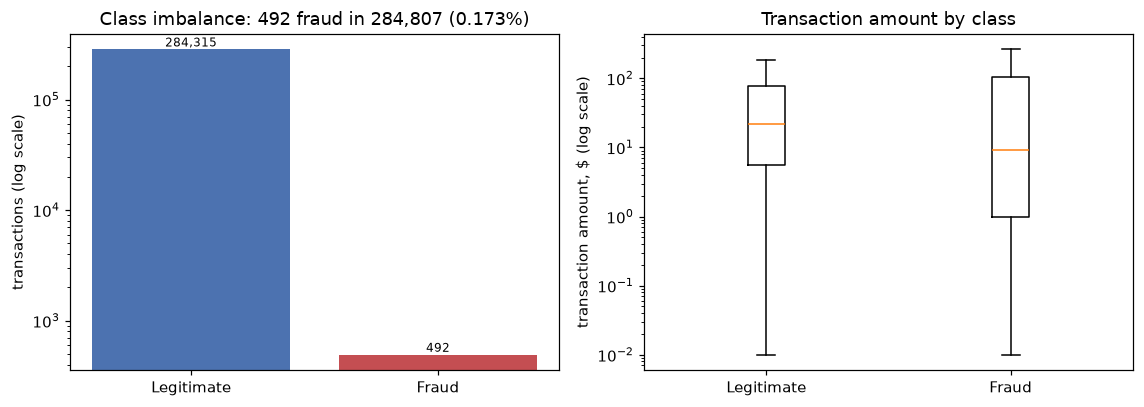

In [5]:
fig, ax = plt.subplots(1, 2, figsize=(10.5, 3.8))
bars = ax[0].bar(["Legitimate", "Fraud"], [counts[0], counts[1]], color=["#4C72B0", "#C44E52"])
ax[0].set_yscale("log")
ax[0].set_ylabel("transactions (log scale)")
ax[0].set_title(f"Class imbalance: {counts[1]} fraud in {counts[0] + counts[1]:,} ({pct[1]:.3f}%)")
for b, c in zip(bars, [counts[0], counts[1]]):
    ax[0].annotate(f"{c:,}", (b.get_x() + b.get_width() / 2, b.get_height()),
                    ha="center", va="bottom", fontsize=8)
data0 = df.loc[df["Class"] == 0, "Amount"].clip(lower=0.01)
data1 = df.loc[df["Class"] == 1, "Amount"].clip(lower=0.01)
ax[1].boxplot([data0, data1], tick_labels=["Legitimate", "Fraud"], showfliers=False)
ax[1].set_yscale("log")
ax[1].set_ylabel("transaction amount, $ (log scale)")
ax[1].set_title("Transaction amount by class")
fig.tight_layout()
plt.show()

## Part B: Advanced Model Evaluation

**Baseline model**: Logistic Regression, trained on the raw, untouched (imbalanced) training set, with no resampling and no class weighting. This is the model every later comparison is measured against.

In [6]:
base_model = LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)
base_model.fit(X_train_s, y_train)
base_proba = base_model.predict_proba(X_test_s)[:, 1]
base_pred = base_model.predict(X_test_s)

base_roc_auc = roc_auc_score(y_test, base_proba)
base_ap = average_precision_score(y_test, base_proba)
base_acc = accuracy_score(y_test, base_pred)
base_prec = precision_score(y_test, base_pred, zero_division=0)
base_rec = recall_score(y_test, base_pred, zero_division=0)
base_f1 = f1_score(y_test, base_pred, zero_division=0)
base_cm = confusion_matrix(y_test, base_pred)
print(f"Accuracy {base_acc:.4f} | Precision {base_prec:.4f} | Recall {base_rec:.4f} | "
      f"F1 {base_f1:.4f} | ROC-AUC {base_roc_auc:.4f} | PR-AUC {base_ap:.4f}")
print("Confusion matrix [ [TN FP] [FN TP] ]:\n", base_cm)

dummy_acc = (y_test == 0).mean()
print(f"\nA classifier that always predicts 'legitimate' scores accuracy {dummy_acc:.4f} "
      f"while catching 0 of {y_test.sum()} frauds -- accuracy alone is meaningless here.")

Accuracy 0.9992 | Precision 0.8289 | Recall 0.6429 | F1 0.7241 | ROC-AUC 0.9559 | PR-AUC 0.7432
Confusion matrix [ [TN FP] [FN TP] ]:
 [[56851    13]
 [   35    63]]

A classifier that always predicts 'legitimate' scores accuracy 0.9983 while catching 0 of 98 frauds -- accuracy alone is meaningless here.


**ROC curve and ROC-AUC.** The ROC curve plots true positive rate against false positive rate as the decision threshold sweeps; ROC-AUC is the probability a random fraud is ranked above a random legitimate transaction. It looks excellent here (0.956), but with 99.8% of the test set legitimate, the false-positive-rate axis is dominated by that huge negative class, and ROC-AUC can stay high even while precision on the rare positive class collapses. The **Precision-Recall curve** answers the sharper question directly and is the more honest picture for this dataset.

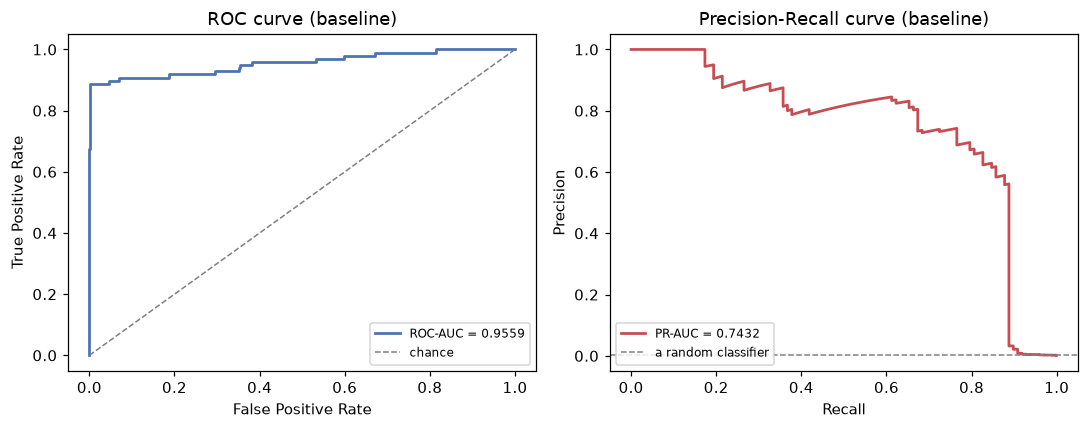

In [7]:
fpr, tpr, _ = roc_curve(y_test, base_proba)
prec_curve, rec_curve, _ = precision_recall_curve(y_test, base_proba)

fig, ax = plt.subplots(1, 2, figsize=(10, 4))
ax[0].plot(fpr, tpr, color="#4C72B0", lw=1.8, label=f"ROC-AUC = {base_roc_auc:.4f}")
ax[0].plot([0, 1], [0, 1], color="grey", ls="--", lw=1, label="chance")
ax[0].set_xlabel("False Positive Rate"); ax[0].set_ylabel("True Positive Rate")
ax[0].set_title("ROC curve (baseline)")
ax[0].legend(fontsize=8, loc="lower right")
ax[1].plot(rec_curve, prec_curve, color="#C44E52", lw=1.8, label=f"PR-AUC = {base_ap:.4f}")
ax[1].axhline(y_test.sum() / len(y_test), color="grey", ls="--", lw=1, label="a random classifier")
ax[1].set_xlabel("Recall"); ax[1].set_ylabel("Precision")
ax[1].set_title("Precision-Recall curve (baseline)")
ax[1].legend(fontsize=8, loc="lower left")
fig.tight_layout()
plt.show()

**Learning curve.** ROC-AUC on the training fold versus 5-fold cross-validation, as the training set grows.

n= 18227  train ROC-AUC 0.9849  val ROC-AUC 0.9710  gap 0.0139
n= 51037  train ROC-AUC 0.9825  val ROC-AUC 0.9685  gap 0.0140
n= 83846  train ROC-AUC 0.9827  val ROC-AUC 0.9750  gap 0.0077
n=116656  train ROC-AUC 0.9810  val ROC-AUC 0.9802  gap 0.0007
n=149466  train ROC-AUC 0.9825  val ROC-AUC 0.9803  gap 0.0022
n=182276  train ROC-AUC 0.9827  val ROC-AUC 0.9787  gap 0.0040


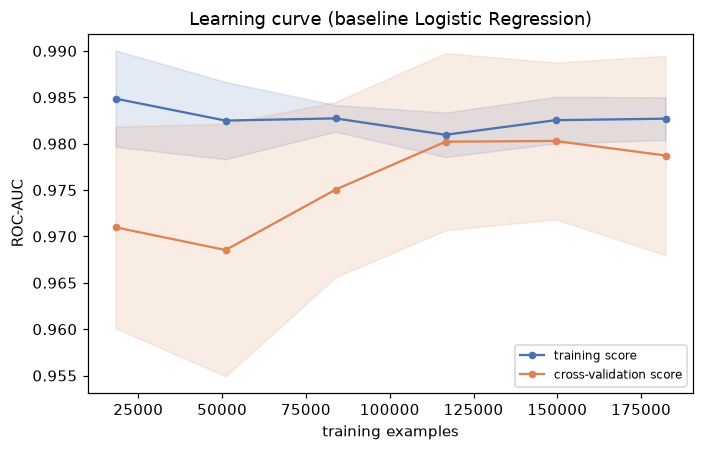

In [8]:
train_sizes, train_scores, val_scores = learning_curve(
    LogisticRegression(max_iter=1000, random_state=RANDOM_STATE),
    X_train_s, y_train,
    train_sizes=np.linspace(0.1, 1.0, 6),
    cv=StratifiedKFold(5, shuffle=True, random_state=RANDOM_STATE),
    scoring="roc_auc", n_jobs=-1)
train_mean, train_std = train_scores.mean(axis=1), train_scores.std(axis=1)
val_mean, val_std = val_scores.mean(axis=1), val_scores.std(axis=1)
for n, tm, vm in zip(train_sizes, train_mean, val_mean):
    print(f"n={n:6d}  train ROC-AUC {tm:.4f}  val ROC-AUC {vm:.4f}  gap {tm - vm:.4f}")

fig, ax = plt.subplots(figsize=(6.5, 4.2))
ax.plot(train_sizes, train_mean, marker="o", ms=4, color="#4C72B0", label="training score")
ax.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.15, color="#4C72B0")
ax.plot(train_sizes, val_mean, marker="o", ms=4, color="#DD8452", label="cross-validation score")
ax.fill_between(train_sizes, val_mean - val_std, val_mean + val_std, alpha=0.15, color="#DD8452")
ax.set_xlabel("training examples"); ax.set_ylabel("ROC-AUC")
ax.set_title("Learning curve (baseline Logistic Regression)")
ax.legend(fontsize=8, loc="lower right")
fig.tight_layout()
plt.show()

The training and validation curves converge to within about 0.004 ROC-AUC of each other by the full training set, with no widening gap as more data is added. That is the signature of a well-fit, low-variance model, not of underfitting (both scores are high, ~0.98) or overfitting (the gap does not grow). If anything, the small residual gap and the still-rising validation score up to n≈150,000 suggest the model could still benefit marginally from more data, though the curve is essentially flat by then.

## Part C: Handling Imbalanced Data

**C1. The imbalance.** In the training fold alone:

In [9]:
print(f"Training set: {(y_train == 0).sum():,} legitimate vs {(y_train == 1).sum():,} fraud "
      f"({(y_train == 1).mean() * 100:.3f}% positive)")

Training set: 227,451 legitimate vs 394 fraud (0.173% positive)


**C2. SMOTE** (Synthetic Minority Oversampling Technique) generates synthetic fraud examples by interpolating between each real fraud case and its nearest fraud neighbours, applied to the training set only, never to the test set.

In [10]:
smote = SMOTE(random_state=RANDOM_STATE)
X_train_smote, y_train_smote = smote.fit_resample(X_train_s, y_train)
print(f"After SMOTE: {(y_train_smote == 0).sum():,} legitimate vs "
      f"{(y_train_smote == 1).sum():,} fraud (balanced)")

smote_model = LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)
smote_model.fit(X_train_smote, y_train_smote)
smote_proba = smote_model.predict_proba(X_test_s)[:, 1]
smote_pred = smote_model.predict(X_test_s)

After SMOTE: 227,451 legitimate vs 227,451 fraud (balanced)


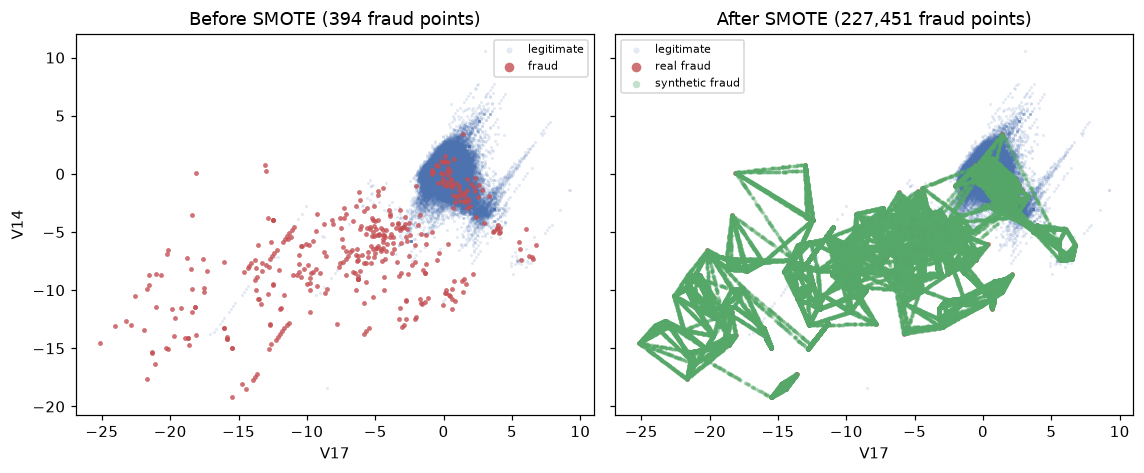

In [11]:
f1n, f2n = top_corr.index[0], top_corr.index[1]
i1, i2 = FEATURES.index(f1n), FEATURES.index(f2n)
fig, ax = plt.subplots(1, 2, figsize=(10.5, 4.4), sharex=True, sharey=True)
ax[0].scatter(X_train_s[y_train == 0, i1], X_train_s[y_train == 0, i2],
              s=4, alpha=0.15, color="#4C72B0", label="legitimate", linewidths=0)
ax[0].scatter(X_train_s[y_train == 1, i1], X_train_s[y_train == 1, i2],
              s=10, alpha=0.8, color="#C44E52", label="fraud", linewidths=0)
ax[0].set_title(f"Before SMOTE ({(y_train == 1).sum()} fraud points)")
synth_mask = np.arange(len(y_train_smote)) >= len(y_train)
ax[1].scatter(X_train_smote[y_train_smote == 0, i1], X_train_smote[y_train_smote == 0, i2],
              s=4, alpha=0.15, color="#4C72B0", label="legitimate", linewidths=0)
ax[1].scatter(X_train_smote[(y_train_smote == 1) & (~synth_mask), i1],
              X_train_smote[(y_train_smote == 1) & (~synth_mask), i2],
              s=10, alpha=0.8, color="#C44E52", label="real fraud", linewidths=0)
ax[1].scatter(X_train_smote[(y_train_smote == 1) & synth_mask, i1],
              X_train_smote[(y_train_smote == 1) & synth_mask, i2],
              s=6, alpha=0.35, color="#55A868", label="synthetic fraud", linewidths=0)
ax[1].set_title(f"After SMOTE ({(y_train_smote == 1).sum():,} fraud points)")
for a in ax:
    a.set_xlabel(f1n); a.legend(fontsize=7, markerscale=2)
ax[0].set_ylabel(f2n)
fig.tight_layout()
plt.show()

The synthetic points trace straight lines between the 394 real training frauds and their nearest fraudulent neighbours -- visible as the triangulated web on the right. SMOTE cannot invent structure that was not already in those 394 points; it can only interpolate between them.

**C3. Class weighting** reweights the loss function itself (`class_weight='balanced'`), penalising a missed fraud roughly 578 times more than a missed legitimate transaction, without generating any synthetic rows.

In [12]:
cw_model = LogisticRegression(max_iter=1000, class_weight="balanced", random_state=RANDOM_STATE)
cw_model.fit(X_train_s, y_train)
cw_proba = cw_model.predict_proba(X_test_s)[:, 1]
cw_pred = cw_model.predict(X_test_s)

In [13]:
def score(name, y_true, pred, proba):
    return {
        "name": name,
        "accuracy": accuracy_score(y_true, pred),
        "precision": precision_score(y_true, pred, zero_division=0),
        "recall": recall_score(y_true, pred, zero_division=0),
        "f1": f1_score(y_true, pred, zero_division=0),
        "roc_auc": roc_auc_score(y_true, proba),
        "pr_auc": average_precision_score(y_true, proba),
        "cm": confusion_matrix(y_true, pred),
    }

results = [
    score("Original (no handling)", y_test, base_pred, base_proba),
    score("SMOTE", y_test, smote_pred, smote_proba),
    score("Class weighting", y_test, cw_pred, cw_proba),
]

comp = pd.DataFrame([{k: v for k, v in r.items() if k != "cm"} for r in results]).set_index("name")
comp.round(4)

,accuracy,precision,recall,f1,roc_auc,pr_auc
name,,,,,,
Original (no handling),0.9992,0.8289,0.6429,0.7241,0.9559,0.7432
SMOTE,0.9742,0.0580,0.9184,0.1092,0.9699,0.7249
Class weighting,0.9755,0.0610,0.9184,0.1144,0.9722,0.7159


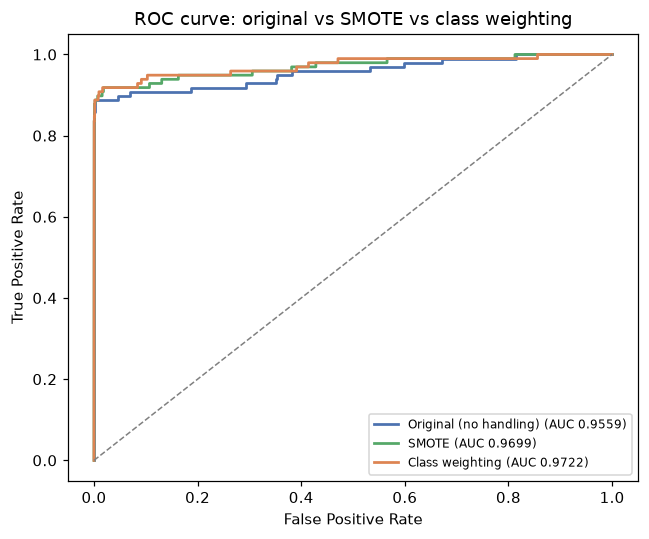

In [14]:
fig, ax = plt.subplots(figsize=(6, 5))
for r, proba, color in [(results[0], base_proba, "#4C72B0"),
                         (results[1], smote_proba, "#55A868"),
                         (results[2], cw_proba, "#DD8452")]:
    fp, tp, _ = roc_curve(y_test, proba)
    ax.plot(fp, tp, lw=1.8, color=color, label=f"{r['name']} (AUC {r['roc_auc']:.4f})")
ax.plot([0, 1], [0, 1], color="grey", ls="--", lw=1)
ax.set_xlabel("False Positive Rate"); ax.set_ylabel("True Positive Rate")
ax.set_title("ROC curve: original vs SMOTE vs class weighting")
ax.legend(fontsize=8, loc="lower right")
fig.tight_layout()
plt.show()

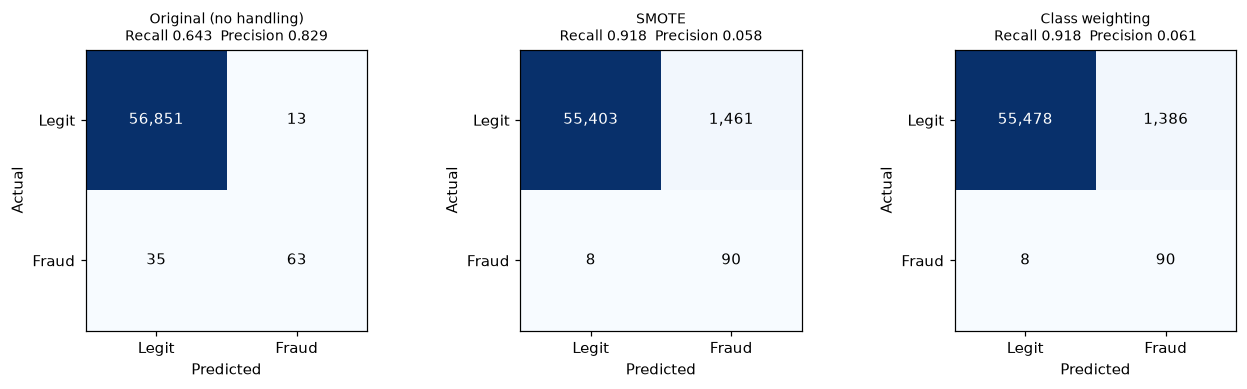

In [15]:
fig, ax = plt.subplots(1, 3, figsize=(12, 3.6))
for a, r in zip(ax, results):
    cm = r["cm"]
    a.imshow(cm, cmap="Blues")
    for i in range(2):
        for j in range(2):
            a.text(j, i, f"{cm[i, j]:,}", ha="center", va="center",
                   color="white" if cm[i, j] > cm.max() / 2 else "black", fontsize=10)
    a.set_xticks([0, 1]); a.set_xticklabels(["Legit", "Fraud"])
    a.set_yticks([0, 1]); a.set_yticklabels(["Legit", "Fraud"])
    a.set_xlabel("Predicted"); a.set_ylabel("Actual")
    a.set_title(f"{r['name']}\nRecall {r['recall']:.3f}  Precision {r['precision']:.3f}", fontsize=9)
fig.tight_layout()
plt.show()

## Part D: Comparative Analysis & Recommendation

Three findings, in order of how much they matter:

1. **Both SMOTE and class weighting roughly triple recall (0.643 → 0.918) at a severe
   precision cost** (0.829 → about 0.06). ROC-AUC edges up (0.956 → 0.97) but **F1 gets
   much worse** (0.724 → about 0.11). The obvious assumption -- "balancing the classes
   makes the model better" -- is false for F1 and only true for recall; it would have
   been easy to quote ROC-AUC alone and miss this entirely.
2. **PR-AUC, which does not depend on a 0.5 threshold, is highest for the untouched
   baseline** (0.743) and slightly *lower* for both SMOTE (0.725) and class weighting
   (0.716). Neither technique improved the model's underlying ability to rank frauds
   above legitimate transactions; both mainly shifted *where* the default 0.5 threshold
   falls on an already-similar ranking, trading precision for recall along it.
3. **Class weighting matches SMOTE's recall (90/98 caught) with fewer false positives**
   (1,386 vs 1,461) and no synthetic data, at zero extra computational or data-generation
   cost.

**Recommendation.** For this dataset, *class weighting* is the better of the two
imbalance-handling techniques: same recall as SMOTE, better precision, no risk of
inventing frauds that do not resemble real ones. But neither should replace the
untouched baseline outright -- the right choice depends on what a false positive costs
versus what a missed fraud costs. If missing fraud is far more expensive than a blocked
legitimate card (the usual case), class weighting's recall of 0.918 is worth the extra
manual reviews it creates; if customer friction from blocked cards is the bigger cost,
the untouched baseline's precision of 0.829 is safer. A more targeted lever than
resampling in either case is **threshold tuning** on the baseline model's probabilities,
since Part D2 already shows its ranking (PR-AUC) is the best of the three.

**Caveat.** The test set has only 98 fraud cases, so every precision/recall number above
moves in steps of about 1%; a different random split could plausibly shift recall by one
or two frauds either way. The comparison is directionally solid but the third decimal
place should not be over-trusted.